In [1]:
import os, sys
import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from datetime import date

In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.titlesize'] = 8    # Size of the plot title
plt.rcParams['axes.labelsize'] = 8    # Size of x and y labels
plt.rcParams['xtick.labelsize'] = 7   # Size of x-tick labels
plt.rcParams['ytick.labelsize'] = 7   # Size of y-tick labels
plt.rcParams['legend.fontsize'] = 7
plt.rcParams['font.size'] = 8

plt.rcParams.update({
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 2,
    'ytick.minor.size': 2,
    'xtick.major.pad': 2,
    'ytick.major.pad': 2,
    'axes.linewidth': 0.8,
})

cm_to_inch = 2.54

In [3]:
sys.path.append(os.path.abspath('../code/'))

from HOC_amplitude_functions import compute_amp_spectrum_adaptive

In [4]:
outputdir = os.path.join ('../results/alternative', str (date.today ()))
os.makedirs(outputdir, exist_ok=True)

In [5]:
save = True

In [6]:
def compute_Am_RMF (M, sigma_a, sigma_e, max_m=1) :

    # binomial coefficients
    binom_coeffs = np.array ([math.comb (M, m) for m in range (M+1)])
    # total variance
    yvar = M * sigma_a**2 + 2**(-M) * sigma_e**2 * (2**M - 1)
    
    Am = np.zeros (max_m+1)
    for i in range (1,max_m+1) :
        if i == 1 :
            Am[i] = M * sigma_a**2

        # epistatic component
        Am[i] += 2**(-M) * sigma_e**2 * binom_coeffs[i]

    return Am / yvar

def compute_Am_LK (M, L, K) :    
    Am    = np.zeros ( L+1 )
    bound = np.min ([K, M])
    for i in range (1,bound+1) :
        geom_i = np.array ([2**(-j) * math.comb (M-i,j-i) * math.comb (L-M,K-j) for j in range (i,bound+1)])
        #print (geom_i)
        Am[i]  = math.comb (M, i) * np.sum (geom_i)

    Am /= math.comb (L,K)
    
    return Am / np.sum (Am)

def A_m (m, M, L, K, sigma=1):
    total = 0.0
    bound = np.min ([M, K])
    for j in range(m, bound+1):
        total += (2.0 ** (-j)) * math.comb(M - m, j - m) * math.comb(L - M, K - j)
        #print ((2.0 ** (-j)) * math.comb(M - m, j - m) * math.comb(L - M, K - j))
    total *= math.comb(M, m)
    denom = math.comb(L, K)
    return sigma ** 2 * total / denom if denom > 0 else 0.0

def theory_R1_and_R2minusR1(M, L, K, sigma=1):
    As = [A_m(m, M, L, K, sigma) for m in range(1, M + 1)]
    #print (As / np.sum (As))
    total = sum(As)
    if total <= 0:
        return np.nan, np.nan
    return As[0] / total, As[1] / total


def R1_hoc_trajectory (M, mug, sigmag) :

    Sg  = M * (sigmag**2 + mug**2) + 2**M - M
    num = M * Sg + 2 * math.comb (M, 3) * mug**2
    denom = (2**M - 1)*Sg - M * (M-1) * mug**2

    return num / denom

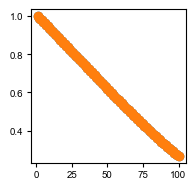

In [7]:
M = 4
L = 100
K_theory_grid = np.arange (1, L+1)

# checking calculations
theory_R1 = np.array([theory_R1_and_R2minusR1(M,L,K)[0] for K in K_theory_grid])
mine = np.array ([compute_Am_LK (M,L,K)[1] for K in K_theory_grid])

plt.rcParams['figure.figsize'] = (2,2)
plt.scatter (K_theory_grid, mine)
plt.scatter (K_theory_grid, theory_R1)
plt.show ()

In [8]:
L = 100
Mlist = [4,8,16]
sigma_es = np.logspace (-2,2,20)
max_m = 4

# compute amplitude spectrum for the RMF
Am_rmf = np.zeros ((len (Mlist), len (sigma_es), max_m+1))
ct = 0
for m in Mlist :
    for i in range (len (sigma_es)) :
        Am_rmf[ct,i,:] = compute_Am_RMF (m, sigma_a=1, sigma_e=sigma_es[i], max_m=np.min (Mlist))
    ct += 1

In [9]:
# compute amplitude spectrum for the LK model
Ks = np.arange (1,L+1,1)

Am_LK = np.zeros ((len (Mlist), len (Ks), L+1))
ct = 0
for m in Mlist :
    for i in range (len (Ks)) :
        Am_LK[ct,i,:] = compute_Am_LK (m, L=L, K=Ks[i])
    ct += 1

In [10]:
fig, axs = plt.subplots (1,2,sharex=False, sharey=False, constrained_layout=True,
                         figsize=(10/cm_to_inch, 4/cm_to_inch))

colors = ['blue','purple','orange','yellow']

ax = axs[0]
for i in range (len (Mlist)) :
    ax.plot (sigma_es, Am_rmf[i,:,1], label=Mlist[i], color=colors[i], lw=1)
    ax.plot (sigma_es, Am_rmf[i,:,2], linestyle='--', color=colors[i], lw=1)
    
    ax.scatter (np.max (sigma_es)*2, Mlist[i] / (2**Mlist[i] - 1), color=colors[i], alpha=.5, s=20, marker='x')
    ax.scatter (np.max (sigma_es)*2, math.comb (Mlist[i],2) / (2**Mlist[i] - 1), color=colors[i], s=20, alpha=.5, marker='v')
ax.set_xscale ('log')
ax.set_title ('A', pad=.5, loc='left', fontweight='bold')

ax.set_ylabel (r'$A_m^{RMF}$')
ax.set_xlabel (r'$\sigma_\epsilon$')
ax.legend (frameon=False, title=r'$M$')

ax = axs[1]
for i in range (len (Mlist)) :
    ax.plot (Ks, Am_LK[i,:,1], label=Mlist[i], color=colors[i], lw=1)
    ax.plot (Ks, Am_LK[i,:,2], linestyle='--', color=colors[i], lw=1)

    ax.scatter (np.max (Ks)+1, Mlist[i] / (2**Mlist[i] - 1), color=colors[i], alpha=.5, s=20, marker='x')
    ax.scatter (np.max (Ks)+1, math.comb (Mlist[i],2) / (2**Mlist[i] - 1), color=colors[i], s=20, alpha=.5, marker='v')

ax.set_xticks (np.arange (0, np.max (Ks)+1, 20), np.arange (0, np.max (Ks)+1, 20))

ax.set_title ('B', pad=.5, loc='left', fontweight='bold')
ax.set_ylabel (r'$A_m^{LK}$')
#ax.set_xticks (np.arange (0,L+1,20), np.arange (0,L+1,20))
ax.set_xlabel (r'$K$')

style_handles = [
    Line2D([0], [0], color='black', lw=1, linestyle='-'),
    Line2D([0], [0], color='black', lw=1, linestyle='--'),
    Line2D([0], [0], color='black', marker='x', linestyle='none', alpha=.5),
    Line2D([0], [0], color='black', marker='v', linestyle='none', alpha=.5),
]
style_labels = [r'$m=1$', r'$m=2$', r'$\tilde A_1^{HoC}$', r'$\tilde A_2^{HoC}$']

axs[1].legend (style_handles, style_labels, 
               handlelength=1.2,     # length of the line/marker swatch
               handletextpad=0.5,    # gap between swatch and label text
               labelspacing=0.3,     # vertical gap between entries
               frameon=False, bbox_to_anchor=(1.05,1))


if save :
    plt.savefig (os.path.join (outputdir, 'Am_alternative.pdf'),
                 bbox_inches='tight')
    plt.close ()
else :
    plt.show ()

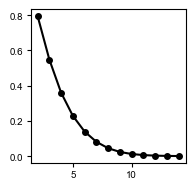

In [11]:
Ms = np.arange (2,15,1)
R1s_hoc = np.zeros (len (Ms))
for i in range (len (Ms)) :
    R1s_hoc[i] = R1_hoc_trajectory (Ms[i], 4, 4)

plt.rcParams['figure.figsize'] = (2,2)
plt.plot (Ms, R1s_hoc, marker='o', color='black', markersize=4)
plt.show ()

In [12]:
mug = sigmag = 4
Amp_hoc = np.zeros ((len (Ms), np.max (Ms)+1))
for i in range (len (Ms)) :
    Mi = Ms[i]
    Amp_hoc[i,:(Mi+1)] = compute_amp_spectrum_adaptive (Mi, mug, sigmag)

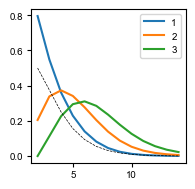

In [13]:
for i in range (1,4) :
    plt.plot (Ms, Amp_hoc[:,i] / np.sum (Amp_hoc, axis=1), label=i)

plt.plot (Ms, (Ms / 2**Ms), color='black', linestyle='--', lw=.5)
plt.legend ()

#plt.yscale ('log')
plt.show ()